# 4b_GBM_MODEL — GBM Training & Artefact Export

Trains (or loads) the **Gradient Boosted quantile** models using optimised
hyperparameters from `gbm_params.json`, applies conformal calibration and a
PCHIP centre-bias correction spline, then bundles all artefacts to
`gbm_artefacts.pkl` for `5b_GBM_TARGETS`.

## 1. Imports & constants

In [1]:
import sys, json, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import PchipInterpolator
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
warnings.filterwarnings('ignore')

# ── paths ──────────────────────────────────────────────────────────────────────
local_data = Path('data')
param_dir  = Path('output/sweeps')
model_dir  = Path('output/models')
fig_dir    = Path('fig/models')
model_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

# ── shared constants ───────────────────────────────────────────────────────────
TEST_FRAC       = 0.20
RANDOM_SEED     = 42
TARGET_COL      = 'q'
q_clip_min      = 0.0
QUANTILES       = [0.05, 0.25, 0.50, 0.75, 0.95]
QUANTILES_DENSE = np.linspace(0.02, 0.98, 49).tolist()
HIST_BIN_W      = 0.010
CONFORMAL_ALPHA = 0.10
SPLINE_PCTLS    = 200   # number of percentile knots for correction spline
FIG_DPI         = 150

from config import *
print(f'obs_model features : {len(obs_model)}')
print(f'q_clip_max         : {q_clip_max} W/m²')
print(f'Test fraction      : {TEST_FRAC}')


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
obs_model features : 21
q_clip_max         : 0.35 W/m²
Test fraction      : 0.2


## 2. Load reference data

In [2]:
df = pd.read_parquet(local_data / 'IHFC_obs.parquet').copy()
print(f'Raw rows: {len(df)}')

df = df.dropna(subset=obs_model)
print(f'After dropna : {len(df)} rows')

if 'weight' in df.columns:
    w_all = df['weight'].values.astype(np.float32)
    w_all = w_all / w_all.mean()
    print(f'Weights  min={w_all.min():.4f}  max={w_all.max():.4f}  mean={w_all.mean():.4f}')
else:
    w_all = np.ones(len(df), dtype=np.float32)
    print('WARNING: no weight column — using uniform weights')


Raw rows: 30848
After dropna : 30847 rows
Weights  min=0.1123  max=3.5262  mean=1.0000


## 3. Load sweep parameters

In [3]:


with open(param_dir / 'gbm_params.json') as fp:
    PARAMS = json.load(fp)


with open(param_paths['gbm'], 'r') as fh:
    PARAMS = json.load(fh)
obs_sel = PARAMS['obs_sel']
assert isinstance(obs_sel, list) and obs_sel, 'obs_sel missing/empty in sweep JSON'
print(f'Using {len(obs_sel)} features from gbm_params.json: {obs_sel}')



print(f'Loaded gbm_params.json')
print(f'  obs_sel ({len(obs_sel)} features)')
for k in ('max_iter','max_depth','learning_rate','min_samples_leaf',
          'max_features','l2_regularization'):
    print(f'  {k:22s} : {PARAMS.get(k)}')


Using 14 features from gbm_params.json: ['REVEAL_S70', 'GEOID', 'MOHO', 'REVEAL_VP50VS80', 'REVEAL_S100', 'SEDIMENT', 'REVEAL_VP60VS70', 'SI', 'FREE_AIR', 'MAG_SEIS_MOHO', 'REVEAL_S80', 'MOHO_GRAV', 'BOUGUER', 'LAB']
Loaded gbm_params.json
  obs_sel (14 features)
  max_iter               : 2000
  max_depth              : 9
  learning_rate          : 0.14740235855688066
  min_samples_leaf       : 49
  max_features           : 0.8853070604484541
  l2_regularization      : 0.4299098165477344


## 4. Train/test split & StandardScaler

In [4]:
X_all = df[obs_sel].values.astype(np.float32)
y_all = df[TARGET_COL].values.astype(np.float32)

assert np.isfinite(X_all).all(), 'NaNs in X_all — check obs_sel'
assert np.isfinite(y_all).all(), 'NaNs in y_all'

X_tr_raw, X_te_raw, y_tr, y_te, w_tr, w_te = train_test_split(
    X_all, y_all, w_all, test_size=TEST_FRAC, random_state=RANDOM_SEED)

cal_frac = float(PARAMS.get('cal_frac', 0.10))
X_tr_raw, X_cal_raw, y_tr, y_cal, w_tr, w_cal = train_test_split(
    X_tr_raw, y_tr, w_tr, test_size=cal_frac, random_state=RANDOM_SEED)

scaler = StandardScaler().fit(X_tr_raw)
X_tr   = scaler.transform(X_tr_raw).astype(np.float32)
X_te   = scaler.transform(X_te_raw).astype(np.float32)

# Held-out calibration slice (last 10 % of train — no additional leakage)
cal_frac = float(PARAMS.get('cal_frac', 0.10))
n_cal    = max(int(len(X_tr) * cal_frac), 100)
X_cal, y_cal, w_cal = X_tr[-n_cal:], y_tr[-n_cal:], w_tr[-n_cal:]

print(f'Train  : {len(y_tr):,}    Test : {len(y_te):,}    Cal slice : {n_cal:,}')
print(f'Features used : {len(obs_sel)}')


Train  : 22,209    Test : 6,170    Cal slice : 2,220
Features used : 14


## 5. Fit GBM (Q05 / Q50 / Q95)

Resumes from pickles if they exist. Each quantile is a separate model.

In [5]:
quantile_losses = PARAMS.get('quantile_losses', [0.05, 0.50, 0.95])
gbm_models = {}
t0 = time.time()

for q in quantile_losses:
    path = model_dir / f'gbm_q{int(q*100):02d}_model.pkl'
    if path.exists():
        print(f'GBM Q{int(q*100):02d}: loading …')
        with open(path, 'rb') as fp:
            gbm_models[q] = pickle.load(fp)
    else:
        print(f'GBM Q{int(q*100):02d}: training …')
        p = dict(
            max_iter          = int(PARAMS['max_iter']),
            max_depth         = PARAMS.get('max_depth'),
            learning_rate     = float(PARAMS['learning_rate']),
            min_samples_leaf  = int(PARAMS['min_samples_leaf']),
            max_features      = PARAMS.get('max_features', 1.0),
            l2_regularization = float(PARAMS.get('l2_regularization', 0.0)),
            random_state      = RANDOM_SEED,
            early_stopping      = bool(PARAMS.get('early_stopping', False)),
            validation_fraction = float(PARAMS.get('validation_fraction', 0.15)),
            n_iter_no_change    = int(PARAMS.get('n_iter_no_change', 30)),
        )
        if q == 0.5:
            p['loss'] = 'squared_error'
        else:
            p['loss']     = 'quantile'
            p['quantile'] = q
        gbm_models[q] = HistGradientBoostingRegressor(**p).fit(
            X_tr, y_tr, sample_weight=w_tr)
        with open(path, 'wb') as fp:
            pickle.dump(gbm_models[q], fp)
        print(f'  saved → {path}')

print(f'Wall time: {(time.time()-t0)/60:.1f} min')


GBM Q05: loading …
GBM Q50: loading …
GBM Q95: loading …
Wall time: 0.0 min


## 6. Test-set predictions + conformal calibration

In [6]:
gbm_q05 = gbm_models[0.05].predict(X_te).astype(np.float32)
gbm_q50 = gbm_models[0.50].predict(X_te).astype(np.float32)
gbm_q95 = gbm_models[0.95].predict(X_te).astype(np.float32)

# conformal calibration on held-out cal slice
cal_05_gbm = gbm_models[0.05].predict(X_cal)
cal_95_gbm = gbm_models[0.95].predict(X_cal)
scores_gbm = np.maximum(cal_05_gbm - y_cal, y_cal - cal_95_gbm)
qhat_gbm   = np.quantile(scores_gbm,
                          (1 - CONFORMAL_ALPHA) * (1 + 1 / len(scores_gbm)))
gbm_conf_lo = np.clip(gbm_q05 - qhat_gbm, q_clip_min, None)
gbm_conf_hi = np.clip(gbm_q95 + qhat_gbm, None, q_clip_max)
print(f'Conformal qhat = {qhat_gbm*1e3:.2f} mW/m²')


Conformal qhat = -0.03 mW/m²


## 7. Correction spline helpers

In [7]:
from lib.utils import weighted_percentile, build_correction_spline

def apply_spline(vals, spline):
    out    = np.full_like(vals, np.nan, dtype=np.float32)
    ok     = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), q_clip_min, q_clip_max)
    return out

print('Spline helpers defined.')


Spline helpers defined.


## 7a. Fit & apply correction spline

Fitting GBM correction spline on calibration set …


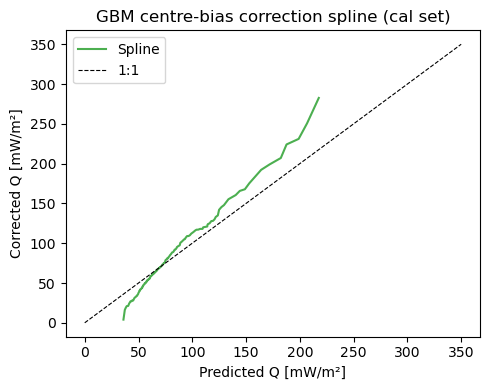

Saved fig/models/gbm_correction_spline.png


In [8]:
print('Fitting GBM correction spline on calibration set …')
gbm_cal_q50 = gbm_models[0.50].predict(X_cal).astype(np.float32)
gbm_spline, gbm_pred_p, gbm_true_p = build_correction_spline(
    gbm_cal_q50, y_cal, w_cal)

gbm_q50_corr   = apply_spline(gbm_q50, gbm_spline)
gbm_q05_corr   = apply_spline(gbm_q05, gbm_spline)
gbm_q95_corr   = apply_spline(gbm_q95, gbm_spline)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(gbm_pred_p*1e3, gbm_true_p*1e3, lw=1.5, color='#4CAF50', label='Spline')
ax.plot([0, q_clip_max*1e3], [0, q_clip_max*1e3], 'k--', lw=0.8, label='1:1')
ax.set_xlabel('Predicted Q [mW/m²]'); ax.set_ylabel('Corrected Q [mW/m²]')
ax.set_title('GBM centre-bias correction spline (cal set)')
ax.legend(); fig.tight_layout()
fig.savefig(fig_dir / 'gbm_correction_spline.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved {fig_dir}/gbm_correction_spline.png')


## 8. Metrics

In [9]:
from lib.utils import empirical_entropy as _empirical_entropy
def empirical_entropy(vals, bin_width=HIST_BIN_W):
    return _empirical_entropy(vals, q_clip_min, q_clip_max, bin_width)

def mean_bias(y_true, y_pred):
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    return float(np.mean(y_pred[valid] - y_true[valid]))

def eval_metrics(y_true, y_pred, y_lo=None, y_hi=None, label=''):
    valid = np.isfinite(y_pred) & np.isfinite(y_true)
    r2    = r2_score(y_true[valid], y_pred[valid])
    rmse  = float(np.sqrt(mean_squared_error(y_true[valid], y_pred[valid])))
    mae   = float(mean_absolute_error(y_true[valid], y_pred[valid]))
    bias  = mean_bias(y_true, y_pred)
    picp  = np.nan
    piw   = np.nan
    if y_lo is not None and y_hi is not None:
        cov  = np.isfinite(y_lo) & np.isfinite(y_hi)
        picp = float(np.mean((y_true[cov] >= y_lo[cov]) & (y_true[cov] <= y_hi[cov])))
        piw  = float(np.mean(y_hi[cov] - y_lo[cov]))
    H = empirical_entropy(y_pred)
    print(f'{label:30s}  R²={r2:.4f}  RMSE={rmse*1e3:.2f} mW/m²  MAE={mae*1e3:.2f}  '
          f'Bias={bias*1e3:.2f}  PICP={picp:.3f}  PI_w={piw*1e3:.1f}  H={H:.3f}')
    return dict(label=label, r2=r2, rmse_mW=rmse*1e3, mae_mW=mae*1e3,
                bias_mW=bias*1e3, picp=picp, pi_width_mW=piw*1e3,
                shannon_H=H, nan_frac=float((~valid).mean()))

print('Metrics helpers defined.')


Metrics helpers defined.


In [10]:
H_obs   = empirical_entropy(y_te)
m_raw   = eval_metrics(y_te, gbm_q50,      y_lo=gbm_q05, y_hi=gbm_q95,
                        label='GBM Q50 raw')
m_corr  = eval_metrics(y_te, gbm_q50_corr, y_lo=gbm_q05_corr, y_hi=gbm_q95_corr,
                        label='GBM Q50 corrected')
m_conf  = eval_metrics(y_te, gbm_q50_corr, y_lo=gbm_conf_lo, y_hi=gbm_conf_hi,
                        label='GBM Q50 corr+conformal')
print(f'Observed entropy : {H_obs:.3f} nat')

metrics_df = pd.DataFrame([m_raw, m_corr, m_conf]).round(4)
metrics_df.to_csv(model_dir / 'gbm_metrics.csv', index=False)
print(f'Saved {model_dir}/gbm_metrics.csv')


GBM Q50 raw                     R²=0.3201  RMSE=37.03 mW/m²  MAE=21.01  Bias=0.15  PICP=0.866  PI_w=78.8  H=2.024
GBM Q50 corrected               R²=0.2292  RMSE=39.43 mW/m²  MAE=23.31  Bias=-1.39  PICP=0.887  PI_w=100.2  H=2.401
GBM Q50 corr+conformal          R²=0.2292  RMSE=39.43 mW/m²  MAE=23.31  Bias=-1.39  PICP=0.866  PI_w=78.7  H=2.401
Observed entropy : 2.471 nat
Saved output/models/gbm_metrics.csv


## 9. Diagnostic figures

In [11]:
from lib.utils import scatter_residuals_fig as _scatter_residuals_fig
def scatter_residuals_fig(rows, suptitle, savepath):
    return _scatter_residuals_fig(rows, suptitle, savepath, q_clip_min, q_clip_max, FIG_DPI)

print('Figure helper defined.')


Figure helper defined.


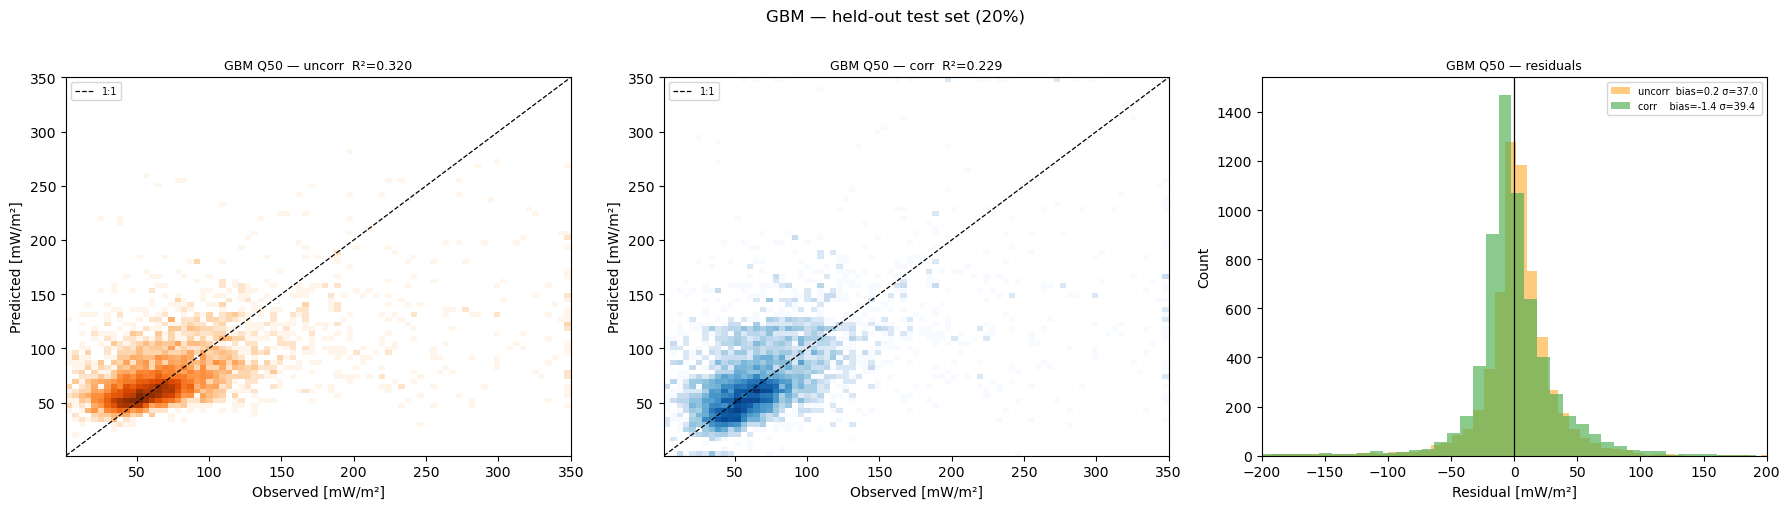

Saved fig/models/gbm_scatter_residuals.png


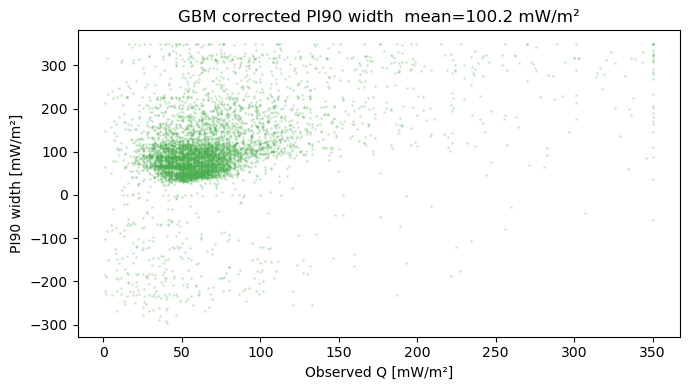

Saved fig/models/gbm_pi_width.png


In [12]:
scatter_residuals_fig(
    rows=[(y_te, gbm_q50, gbm_q50_corr, 'GBM Q50', '#4CAF50')],
    suptitle='GBM — held-out test set (20%)',
    savepath=fig_dir / 'gbm_scatter_residuals.png',
)

fig, ax = plt.subplots(figsize=(7, 4))
pi_width = (gbm_q95_corr - gbm_q05_corr) * 1e3
ax.scatter(y_te * 1e3, pi_width, s=1, alpha=0.2, c='#4CAF50', rasterized=True)
ax.set_xlabel('Observed Q [mW/m²]'); ax.set_ylabel('PI90 width [mW/m²]')
ax.set_title(f'GBM corrected PI90 width  mean={pi_width.mean():.1f} mW/m²')
fig.tight_layout()
fig.savefig(fig_dir / 'gbm_pi_width.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show(); print(f'Saved {fig_dir}/gbm_pi_width.png')


## 10. Bundle artefacts for `5_TARGETS`

In [13]:
artefacts = dict(
    models          = gbm_models,    # dict {quantile: estimator} (canonical key 'models')
    spline          = gbm_spline,    # canonical key 'spline'
    obs_sel         = obs_sel,
    qhat_gbm       = float(qhat_gbm),
    quantile_losses = list(quantile_losses),

    scaler          = scaler,
    CONFORMAL_ALPHA  = CONFORMAL_ALPHA,
    PARAMS          = PARAMS,
)
bundle_path = model_dir / "gbm_artefacts.pkl"
with open(bundle_path, "wb") as fp:
    pickle.dump(artefacts, fp)
print("Bundle saved", bundle_path)
print("Keys:", list(artefacts.keys()))

Bundle saved output/models/gbm_artefacts.pkl
Keys: ['models', 'spline', 'obs_sel', 'qhat_gbm', 'quantile_losses', 'scaler', 'CONFORMAL_ALPHA', 'PARAMS']


In [14]:
print(f'GBM obs_sel  : {len(obs_sel)} features')
print(f'X_tr_raw shape   : {X_tr_raw.shape}')
print(f'GBMs fitted  : {[m.n_iter_ for m in gbm_models.values()]}')

GBM obs_sel  : 14 features
X_tr_raw shape   : (22209, 14)
GBMs fitted  : [92, 79, 68]


In [15]:
[v for v in dir() if 'gbm' in v.lower() or 'mdl' in v.lower() or 'hist' in v.lower()]

['HIST_BIN_W',
 'HIST_BIN_WIDTH',
 'HIST_MAX_BINS',
 'HistGradientBoostingRegressor',
 'cal_05_gbm',
 'cal_95_gbm',
 'gbm_cal_q50',
 'gbm_conf_hi',
 'gbm_conf_lo',
 'gbm_models',
 'gbm_pred_p',
 'gbm_q05',
 'gbm_q05_corr',
 'gbm_q50',
 'gbm_q50_corr',
 'gbm_q95',
 'gbm_q95_corr',
 'gbm_spline',
 'gbm_true_p',
 'qhat_gbm',
 'scores_gbm']

In [16]:


# Unregularised, squared error, max iterations
gbm_test = HistGradientBoostingRegressor(
    loss='squared_error',
    max_iter=1000,
    max_depth=None,       # unlimited depth
    min_samples_leaf=20,
    learning_rate=0.05,
    l2_regularization=0.0,
    random_state=42,
).fit(X_tr, y_tr)

print(f"Train R²: {r2_score(y_tr, gbm_test.predict(X_tr)):.4f}")
print(f"Test  R²: {r2_score(y_te, gbm_test.predict(X_te)):.4f}")

Train R²: 0.5329
Test  R²: 0.3645
